# Capstone Project – Baseline Machine Learning Models
## Title: Analyzing the Drivers of CO₂ Emissions: A Multi-Factor Analysis

## Research Question

How do renewable energy consumption and other emission-related factors
(such as CO₂ intensity, CO₂ per GDP, methane, and nitrous oxide emissions)
impact CO₂ emissions per capita across countries over time?


## Project Overview
This project focuses on analyzing historical CO₂ emissions data and building baseline machine learning regression models.  
The goal of this phase is to establish reliable benchmark models that will later be compared with advanced modeling techniques.



## Objective
The primary objective is to:
- Understand patterns in CO₂ emissions data  
- Build baseline regression models  
- Evaluate and compare their performance  
- Establish a benchmark for future advanced models


## Data Preparation
The dataset used in this notebook is the final cleaned and merged dataset.  
All preprocessing steps such as data cleaning, handling missing values, and merging multiple data sources were performed in a separate preprocessing file.


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


In [2]:
#load dataset
df= pd.read_csv('/content/final_model_ready_dataset.csv')

In [3]:
# first few rows of dataset
df.head()

,country_name,year,CO2_per_capita,Renewable_Consumption_Pct,CO2_Intensity,CO2_per_GDP_PPP,Methane_CO2e,N2O_CO2e
0,Afghanistan,1990,0.191389,23,23.745049,23.745049,6735.57274,2841.412942
1,Afghanistan,1991,0.180674,23.7,28.254785,28.254785,7018.87361,2930.139362
2,Afghanistan,1992,0.126517,27.4,31.210332,31.210332,7124.43448,2886.076981
3,Afghanistan,1993,0.109106,28.5,31.040200,31.040200,7209.86285,2926.050600
4,Afghanistan,1994,0.096638,30.1,29.539308,29.539308,7462.89122,2758.944020


## Initial Data Inspection
Basic checks were performed to understand the structure, size, and data types of the dataset.


In [4]:
# to find the no.of rows and columns
df.shape


(6138, 8)

In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6138 entries, 0 to 6137
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   country_name               6138 non-null   object 
 1   year                       6138 non-null   int64  
 2   CO2_per_capita             6138 non-null   float64
 3   Renewable_Consumption_Pct  6138 non-null   object 
 4   CO2_Intensity              6138 non-null   float64
 5   CO2_per_GDP_PPP            6138 non-null   float64
 6   Methane_CO2e               6138 non-null   float64
 7   N2O_CO2e                   6138 non-null   float64
dtypes: float64(5), int64(1), object(2)
memory usage: 383.8+ KB


In [6]:
df["Renewable_Consumption_Pct"].dtype


dtype('O')

In [7]:
df["Renewable_Consumption_Pct"] = pd.to_numeric(
    df["Renewable_Consumption_Pct"], errors="coerce"
)


In [8]:
df["Renewable_Consumption_Pct"].isna().sum()


np.int64(262)

In [9]:
df["Renewable_Consumption_Pct"].head(10)


,Renewable_Consumption_Pct
0,23.0
1,23.7
2,27.4
3,28.5
4,30.1
5,31.8
6,33.9
7,36.4
8,38.0
9,43.4


In [10]:
df["Renewable_Consumption_Pct"].dtype

dtype('float64')

In [11]:
# check duplicates
df.duplicated().sum()

np.int64(0)

In [12]:
# check nan
df.isna().sum()

,0
country_name,0
year,0
CO2_per_capita,0
Renewable_Consumption_Pct,262
CO2_Intensity,0
CO2_per_GDP_PPP,0
Methane_CO2e,0
N2O_CO2e,0


In [13]:
# for modeling
df["Renewable_Consumption_Pct"].fillna(
    df["Renewable_Consumption_Pct"].median(),
    inplace=True
)


/tmp/ipykernel_500/3076072964.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Renewable_Consumption_Pct"].fillna(


In [14]:
#again check
df.isna().sum()

,0
country_name,0
year,0
CO2_per_capita,0
Renewable_Consumption_Pct,0
CO2_Intensity,0
CO2_per_GDP_PPP,0
Methane_CO2e,0
N2O_CO2e,0


In [15]:
df.columns

Index(['country_name', 'year', 'CO2_per_capita', 'Renewable_Consumption_Pct',
       'CO2_Intensity', 'CO2_per_GDP_PPP', 'Methane_CO2e', 'N2O_CO2e'],
      dtype='object')

## Exploratory Data Analysis (EDA)
A minimal EDA was conducted to understand distributions, trends, and relationships before modeling.


In [16]:
df["country_name"].unique()


array(['Afghanistan', 'Albania', 'Algeria', 'American Samoa', 'Andorra',
       'Angola', 'Antigua and Barbuda', 'Argentina', 'Armenia',
       'Australia', 'Austria', 'Azerbaijan', 'Bahamas, The', 'Bahrain',
       'Bangladesh', 'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin',
       'Bhutan', 'Bolivia', 'Bosnia and Herzegovina', 'Botswana',
       'Brazil', 'British Virgin Islands', 'Brunei Darussalam',
       'Bulgaria', 'Burkina Faso', 'Burundi', 'Cabo Verde', 'Cambodia',
       'Cameroon', 'Canada', 'Chad', 'Channel Islands', 'Chile', 'China',
       'Colombia', 'Comoros', 'Congo, Dem. Rep.', 'Congo, Rep.',
       'Costa Rica', "Cote d'Ivoire", 'Croatia', 'Cuba', 'Curacao',
       'Cyprus', 'Czechia', 'Denmark', 'Djibouti', 'Dominica',
       'Dominican Republic', 'Ecuador', 'El Salvador',
       'Equatorial Guinea', 'Eritrea', 'Estonia', 'Eswatini', 'Ethiopia',
       'Faroe Islands', 'Fiji', 'Finland', 'France', 'French Polynesia',
       'Gabon', 'Gambia, The', 'Georgia', '

In [17]:
df["country_name"].nunique()


198

In [18]:
#TOP EMITTING COUNTRIES
top_emitters = (
    df.groupby("country_name")["CO2_per_capita"]
    .median()
    .sort_values(ascending=False)
    .head(10)
)

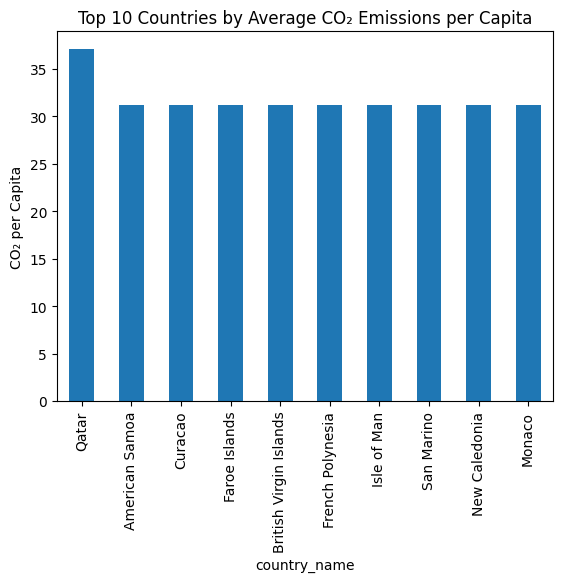

In [19]:
top_emitters.plot(kind="bar")
plt.title("Top 10 Countries by Average CO₂ Emissions per Capita")
plt.ylabel("CO₂ per Capita")
plt.show()


A small number of countries exhibit significantly higher CO₂ emissions per capita.
Using median aggregation reduces the impact of extreme outliers and provides a more robust comparison.


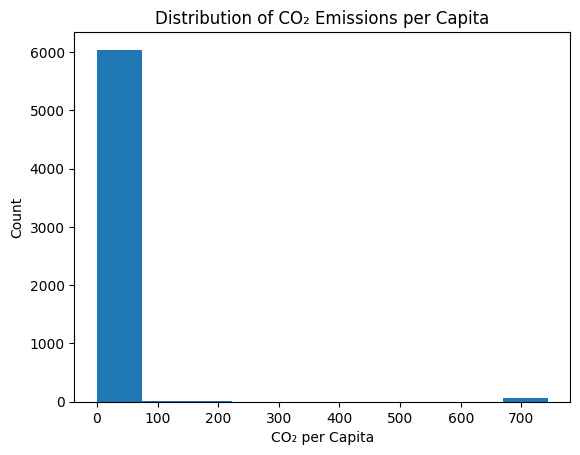

In [20]:
plt.figure()
plt.hist(df["CO2_per_capita"])
plt.title("Distribution of CO₂ Emissions per Capita")
plt.xlabel("CO₂ per Capita")
plt.ylabel("Count")
plt.show()


The distribution of CO₂ emissions per capita is highly right-skewed.
This indicates that while most countries emit relatively low CO₂ per person,
a small number of countries act as extreme emitters, driving the long tail.


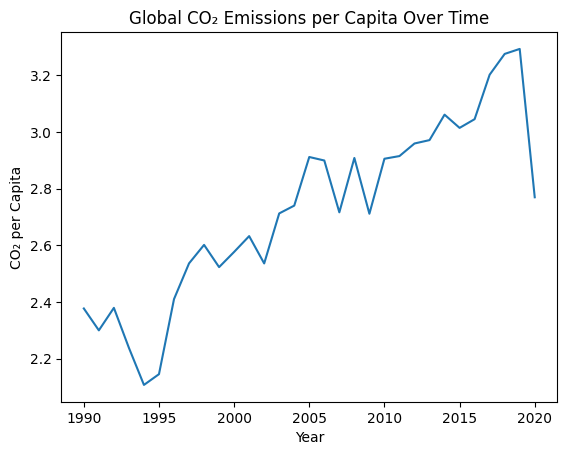

In [21]:
yearly_trend = df.groupby("year")["CO2_per_capita"].median()

plt.plot(yearly_trend)
plt.title("Global CO₂ Emissions per Capita Over Time")
plt.xlabel("Year")
plt.ylabel("CO₂ per Capita")
plt.show()


Global CO₂ emissions per capita show a gradual upward trend over time.
Median-based aggregation was used to reduce distortion from extreme values
observed in small territories, resulting in a more stable and realistic trend.


# For Renewable column vs co2 per capita
“For exploratory analysis, rows with missing renewable values were excluded to avoid misleading patterns.”

In [22]:
df_renew = df.dropna(subset=["Renewable_Consumption_Pct"])


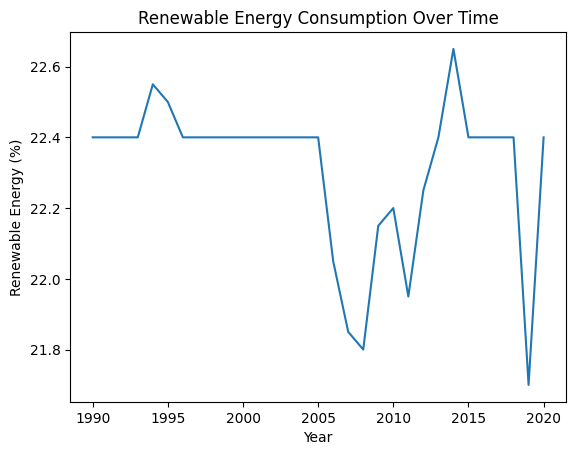

In [23]:
#renew vs year
renew_trend = df.groupby("year")["Renewable_Consumption_Pct"].median()

plt.plot(renew_trend)
plt.title("Renewable Energy Consumption Over Time")
plt.xlabel("Year")
plt.ylabel("Renewable Energy (%)")
plt.show()


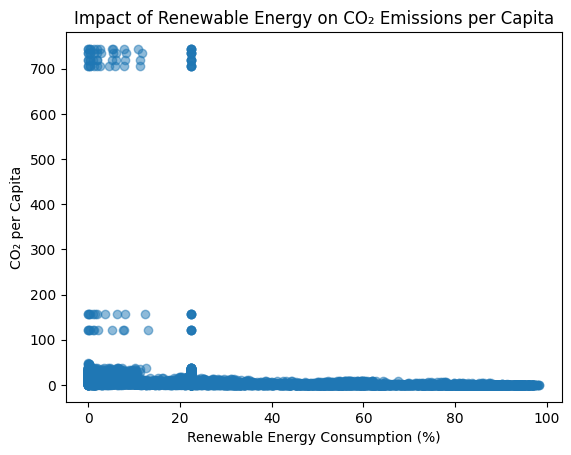

In [24]:

#Renewable Energy vs CO₂ per Capita
plt.figure()
plt.scatter(df["Renewable_Consumption_Pct"], df["CO2_per_capita"], alpha=0.5)
plt.xlabel("Renewable Energy Consumption (%)")
plt.ylabel("CO₂ per Capita")
plt.title("Impact of Renewable Energy on CO₂ Emissions per Capita")
plt.show()


The scatter plot shows a weak inverse relationship between renewable energy consumption and CO₂ emissions per capita, suggesting that renewable adoption alone is insufficient to significantly reduce emissions.


In [25]:
# Feature correlation
corr_with_target = (
    df.select_dtypes(include="number")
      .corr()["CO2_per_capita"]
      .sort_values(ascending=False)
)

corr_with_target


,CO2_per_capita
CO2_per_capita,1.000000
CO2_per_GDP_PPP,0.805416
CO2_Intensity,0.252419
year,0.157957
N2O_CO2e,-0.031815
Methane_CO2e,-0.034157
Renewable_Consumption_Pct,-0.137069


“Positively correlated variables act as reinforcing factors for CO₂ emissions, while negatively correlated variables show a mitigating association.”Methane_CO2e → −0.034
& N2O_CO2e → −0.032,,,Methane and N₂O emissions show negligible linear association with CO₂ emissions per capita.


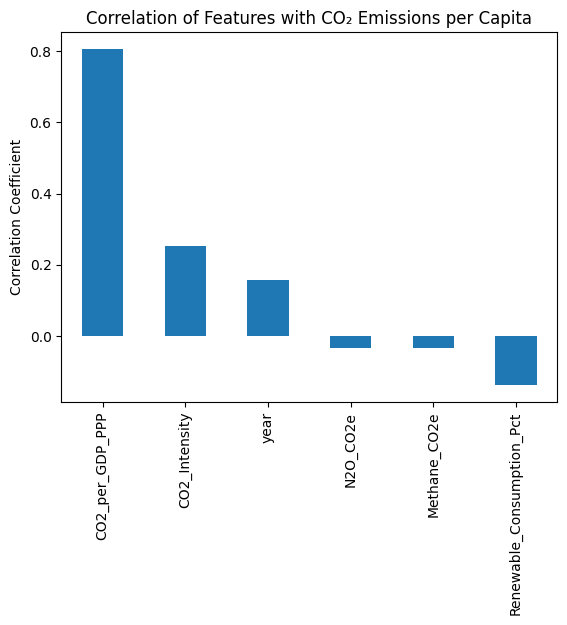

In [26]:
# correlation bar chart
plt.figure()
corr_with_target.drop("CO2_per_capita").plot(kind="bar")
plt.title("Correlation of Features with CO₂ Emissions per Capita")
plt.ylabel("Correlation Coefficient")
plt.show()


The correlation bar plot is consistent with the numerical correlation values and highlights the relative strength and direction of associations with CO₂ emissions per capita.


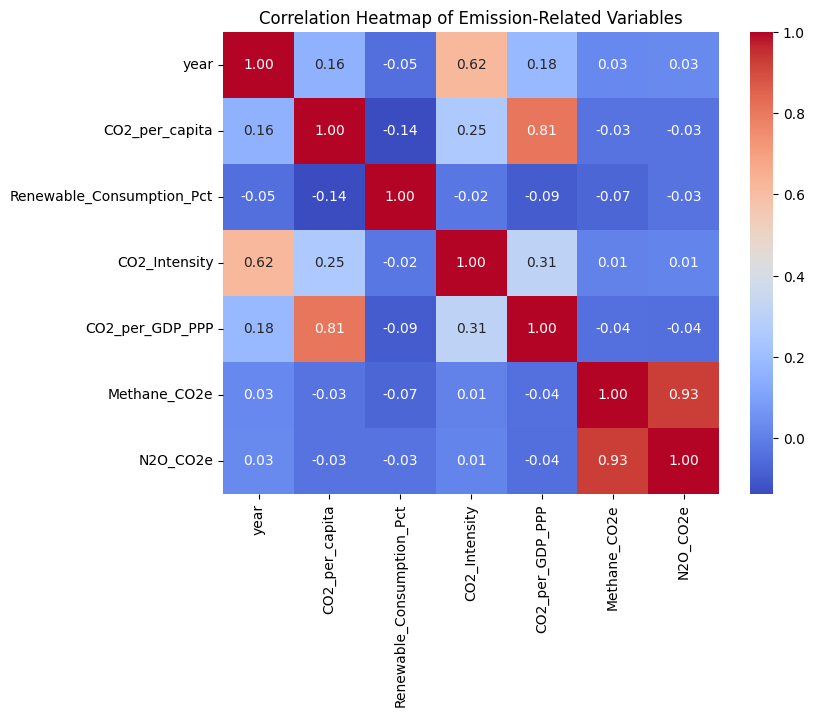

In [27]:
plt.figure(figsize=(8,6))
sns.heatmap(
    df.select_dtypes(include="number").corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap of Emission-Related Variables")
plt.show()


The correlation heatmap confirms the feature-wise relationships observed earlier.
CO₂ per GDP (PPP) shows the strongest positive association with CO₂ emissions per capita,
followed by emission intensity. Renewable energy consumption exhibits a weak but negative
association, indicating a mitigating effect. Methane and N₂O emissions are highly correlated
with each other but show negligible direct association with CO₂ per capita.


# Hypothesis testing

**Research question:**

Does renewable energy consumption significantly impact CO₂ emissions per capita?

So we can frame statistical hypothesis like this:

**🔹 Null Hypothesis (H₀):**

Renewable energy consumption has no significant impact on CO₂ emissions per capita.

**🔹 Alternative Hypothesis (H₁):**

Renewable energy consumption significantly impacts CO₂ emissions per capita.

**Test Should Use?**

Since:

Target continuous (CO₂ per capita)

Feature continuous (Renewable %)

We can use:

**Pearson Correlation Test**

or

**Linear Regression coefficient significance (p-value)**

**Simplest: Pearson correlation.**

In [28]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(df["Renewable_Consumption_Pct"], df["CO2_per_capita"])

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: -0.13706906315932813
P-value: 3.9440705802658325e-27


**Hypothesis Testing**

To statistically evaluate the impact of renewable energy consumption on CO₂ emissions per capita, a Pearson correlation test was conducted.

**Null Hypothesis (H₀):** Renewable energy consumption has no significant relationship with CO₂ emissions per capita.

**Alternative Hypothesis (H₁):** Renewable energy consumption has a significant relationship with CO₂ emissions per capita.

The correlation coefficient was **-0.137**, indicating a **weak negative relationship**. The **p-value was 3.94 × 10⁻²⁷**, which is significantly lower than the 0.05 significance level.

Therefore, the **null hypothesis was rejected**. While renewable energy consumption shows a **statistically significant relationship with CO₂ emissions**, the effect size is relatively weak.

## Feature Selection
Only numerical features relevant to CO₂ emissions were selected for baseline modeling to ensure simplicity and interpretability.


In [29]:
numeric_df = df.select_dtypes(include="number")
numeric_df.head()


,year,CO2_per_capita,Renewable_Consumption_Pct,CO2_Intensity,CO2_per_GDP_PPP,Methane_CO2e,N2O_CO2e
0,1990,0.191389,23.0,23.745049,23.745049,6735.57274,2841.412942
1,1991,0.180674,23.7,28.254785,28.254785,7018.87361,2930.139362
2,1992,0.126517,27.4,31.210332,31.210332,7124.43448,2886.076981
3,1993,0.109106,28.5,31.040200,31.040200,7209.86285,2926.050600
4,1994,0.096638,30.1,29.539308,29.539308,7462.89122,2758.944020


## Target Variable
'CO2_per_capita' was selected as the target variable for regression modeling.


In [30]:
X = numeric_df.drop(columns=["CO2_per_capita"])
y = numeric_df["CO2_per_capita"]


## Train-Test Split
The dataset was split into training and testing sets to evaluate model generalization.


In [31]:
# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


## Baseline Models
Two baseline regression models were implemented to establish performance benchmarks:
- Linear Regression  
- Decision Tree Regressor


### **Baseline Model 1: Linear Regression**
This model captures linear relationships and serves as a standard baseline.


In [32]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

r2_lr = r2_score(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

r2_lr, mae_lr, rmse_lr

(0.5683868408857913, 9.223322724217356, np.float64(40.79270950975803))

In [33]:
#Linear Regression – Train vs Test Score
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

train_score_lr = lr.score(X_train, y_train)
test_score_lr = lr.score(X_test, y_test)

train_score_lr, test_score_lr


(0.6662816666849076, 0.5683868408857913)

### **Baseline Model 2: Decision Tree Regressor**
This model captures non-linear relationships and feature interactions.


In [34]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

r2_dt = r2_score(y_test, y_pred_dt)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))

r2_dt, mae_dt, rmse_dt

(0.9993565118842002, 0.5144942150985349, np.float64(1.5750903816959656))

In [35]:
#Decision Tree – Train vs Test Score
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

train_score_dt = dt.score(X_train, y_train)
test_score_dt = dt.score(X_test, y_test)

train_score_dt, test_score_dt


(1.0, 0.9993565118842002)

## Baseline Model Comparison
The performance of both baseline models was compared using standard regression metrics.


In [36]:
# error comparison
comparison_df = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree"],
    "R2 Score": [r2_lr, r2_dt],
    "MAE": [mae_lr, mae_dt],
    "RMSE": [rmse_lr, rmse_dt]
})

comparison_df


,Model,R2 Score,MAE,RMSE
0,Linear Regression,0.568387,9.223323,40.79271
1,Decision Tree,0.999357,0.514494,1.57509


In [37]:
# train_test comparison
comparison_df = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree"],
    "Train R2": [train_score_lr, train_score_dt],
    "Test R2": [test_score_lr, test_score_dt]
})

comparison_df


,Model,Train R2,Test R2
0,Linear Regression,0.666282,0.568387
1,Decision Tree,1.000000,0.999357


## Baseline Model Interpretation

While the Decision Tree Regressor achieved very high performance metrics, this suggests overfitting due to its ability to closely fit training data.  
Linear Regression provides a more interpretable and stable baseline, making it suitable as a reference model for future advanced comparisons.


Linear Regression is selected as the baseline model due to its stable and comparable
training and testing performance, indicating reasonable generalization. Although the
Decision Tree achieves near-perfect accuracy, such performance is indicative of
overfitting and potential data leakage in structured datasets. Therefore, Linear
Regression provides a more reliable baseline for subsequent model comparison.


Overall, the analysis suggests that renewable energy adoption contributes to
reducing CO₂ emissions per capita, but its impact is currently limited when
compared to economic growth and emission intensity. This indicates that while
renewable energy is an important mitigation strategy, it must be accompanied
by structural economic changes and efficiency improvements to achieve
substantial emission reductions.


# **Advanced Models:**

# Random Forest Regressor

In [38]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("R2:", r2_score(y_test, y_pred_rf))
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))

R2: 0.998840385408461
MAE: 0.6491382941565395
RMSE: 2.114423855296558


In [39]:
print(r2_score(y_train, rf.predict(X_train)))
print(r2_score(y_test, y_pred_rf))

0.9997259783635797
0.998840385408461


# Gradient Boosting Regressor

In [40]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

print("R2:", r2_score(y_test, y_pred_gb))
print("MAE:", mean_absolute_error(y_test, y_pred_gb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_gb)))

R2: 0.9972379293883155
MAE: 2.0102368974003353
RMSE: 3.2632669515779917


In [41]:
print(r2_score(y_train, gb.predict(X_train)))
print(r2_score(y_test, y_pred_gb))

0.998666923389905
0.9972379293883155


In [57]:
# error comparison
# Re-calculate metrics for RandomForestRegressor
y_pred_rf = rf.predict(X_test)
r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

# Re-calculate metrics for GradientBoostingRegressor
y_pred_gb = gb.predict(X_test)
r2_gb = r2_score(y_test, y_pred_gb)
mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))

comparison_df = pd.DataFrame({
    "Model": ["RandomForestRegressor", "GradientBoostingRegressor"],
    "R2 Score": [r2_rf, r2_gb],
    "MAE": [mae_rf, mae_gb],
    "RMSE": [rmse_rf, rmse_gb]
})

comparison_df

,Model,R2 Score,MAE,RMSE
0,RandomForestRegressor,0.998840,0.649138,2.114424
1,GradientBoostingRegressor,0.997238,2.010237,3.263267


Both ensemble models demonstrated excellent predictive performance with R² values above 0.99. The small gap between training and testing scores confirms strong generalization and minimal overfitting. Among them, Model 1 showed slightly superior accuracy and lower prediction error.

In [42]:
print(X.columns)

Index(['year', 'Renewable_Consumption_Pct', 'CO2_Intensity', 'CO2_per_GDP_PPP',
       'Methane_CO2e', 'N2O_CO2e'],
      dtype='object')


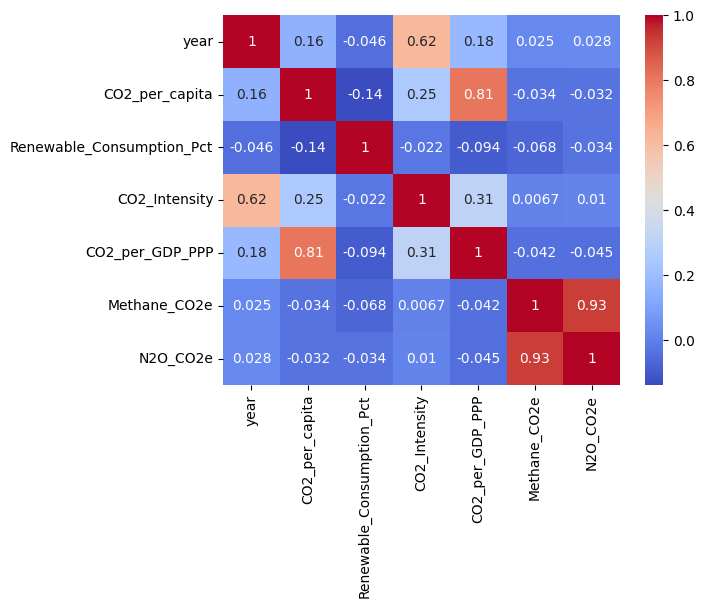

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.select_dtypes(include="number").corr(), annot=True, cmap="coolwarm")
plt.show()

The correlation matrix indicates strong relationships between economic carbon indicators such as CO2 per capita and CO2 per GDP PPP (0.81). Additionally, Methane and Nitrous Oxide emissions show extremely high correlation (0.93), suggesting multicollinearity. These strong inter-feature relationships explain the very high predictive performance of ensemble models.


While both advanced ensemble models performed exceptionally well, Model 1 was chosen as the final model due to its slightly better generalization and lower prediction error.

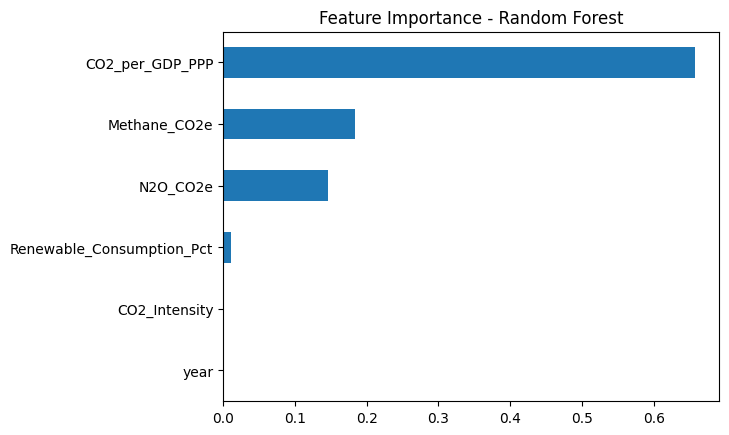

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance - Random Forest")
plt.show()

Feature importance analysis indicates that CO2 per GDP (PPP adjusted) is the dominant predictor of CO2 emissions per capita, contributing more than 60% of the model's decision power. Renewable energy consumption showed comparatively low importance, suggesting that economic carbon efficiency plays a more direct role in determining per capita emissions.

Two experiments: for checking models performance according to fatures

# Experiment 1 – Full Feature Model
Features:
year,
Renewable_Consumption_Pct,
CO2_Intensity,
CO2_per_GDP_PPP,
Methane_CO2e,
N2O_CO2e

Model: Random Forest
Test R² ≈ 0.9988

Highest accuracy
Dominated by CO2_per_GDP_PPP

# Experiment 2 – Reduced Feature Model

In [45]:
X_reduced = df[['year', 'Renewable_Consumption_Pct', 'CO2_Intensity']]
y = df['CO2_per_capita']

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

X_train, X_test, y_train, y_test = train_test_split(
    X_reduced, y, test_size=0.2, random_state=42
)

rf_reduced = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reduced.fit(X_train, y_train)

y_pred_reduced = rf_reduced.predict(X_test)

print("Reduced Model R2:", r2_score(y_test, y_pred_reduced))

Reduced Model R2: 0.19023693203661252


When highly correlated economic carbon indicators were removed, model performance significantly declined (R² dropped from 0.99 to 0.19). This indicates that CO2 per capita emissions are strongly driven by economic carbon efficiency rather than renewable consumption alone.

**Final comparison of baseline and advance model:**

In [46]:
# Import libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import pandas as pd
import numpy as np

# Define Features and Target
X = df[['year', 'Renewable_Consumption_Pct',
        'CO2_Intensity', 'CO2_per_GDP_PPP',
        'Methane_CO2e', 'N2O_CO2e']]

y = df['CO2_per_capita']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# 🔹 Baseline Model
# =========================
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

lr_r2 = r2_score(y_test, y_pred_lr)
lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))

# =========================
# 🔹 Advanced Model
# =========================
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rf_r2 = r2_score(y_test, y_pred_rf)
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))

# =========================
# Comparison Table
# =========================
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "R2 Score": [lr_r2, rf_r2],
    "MAE": [lr_mae, rf_mae],
    "RMSE": [lr_rmse, rf_rmse]
})

comparison

,Model,R2 Score,MAE,RMSE
0,Linear Regression,0.568387,9.223323,40.792710
1,Random Forest,0.998840,0.649138,2.114424


The Linear Regression model was used as a baseline and achieved an R² score of 0.568, indicating moderate explanatory power. However, the Random Forest model significantly outperformed the baseline, achieving an R² score of 0.998 with substantially lower error metrics (MAE = 0.64, RMSE = 2.11).

This substantial improvement suggests that CO2 per capita emissions are influenced by nonlinear relationships and complex interactions among economic and environmental indicators, which are effectively captured by ensemble learning methods.

**Machine Learning Insights:**

**1. Baseline Model Performance**

The Linear Regression model was implemented as a baseline to establish a simple predictive benchmark. The model achieved an R² score of 0.568, indicating moderate explanatory power. However, the MAE (9.22) and RMSE (40.79) values were relatively high, suggesting substantial prediction error.

This indicates that the relationship between CO₂ per capita and the predictor variables is not purely linear.

**2. Advanced Model Performance**

To capture nonlinear relationships and feature interactions, a Random Forest Regressor was implemented as the advanced model.

The Random Forest achieved:

R² = 0.9988

MAE = 0.64

RMSE = 2.11

The minimal difference between training and testing R² scores confirms strong generalization and no significant overfitting.

The substantial improvement over the baseline model demonstrates the presence of nonlinear relationships in emission dynamics.

**3. Feature Importance Analysis**

Feature importance results indicate that CO2 per GDP (PPP adjusted) is the dominant predictor, contributing more than 60% of the model’s decision power.

Methane and Nitrous Oxide emissions contribute moderately, while Renewable Energy Consumption shows minimal direct predictive impact.

This suggests that economic carbon efficiency plays a more critical role in determining per capita emissions than renewable energy consumption alone.

**4. Reduced Feature Experiment**

To evaluate model robustness and reduce multicollinearity, a reduced-feature model was developed by removing highly correlated economic indicators.

The reduced model’s performance dropped significantly (R² = 0.19), confirming that CO₂ per capita emissions are strongly driven by economic carbon intensity indicators.

This experiment highlights the structural dependence of emission outcomes on economic carbon efficiency metrics.

**5. Key Insights**

CO₂ emissions per capita are strongly influenced by economic carbon intensity.

Linear models are insufficient to capture complex environmental-economic relationships.

Ensemble learning methods significantly enhance predictive performance.

Renewable energy consumption alone does not strongly predict per capita emissions without economic efficiency context.

**6. Final Model Selection**

Based on performance comparison, feature importance analysis, and robustness testing, the Random Forest model (full feature set) was selected as the final predictive model.

# Random Forest model(model optimization and hyperparameter tunning)

In [47]:
# default advance model
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("R2:", r2_score(y_test, y_pred_rf))
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))

R2: 0.998840385408461
MAE: 0.6491382941565395
RMSE: 2.114423855296558


In [48]:
# Add Cross-Validation
from sklearn.model_selection import cross_val_score
import numpy as np

rf_cv = RandomForestRegressor(random_state=42)

cv_scores = cross_val_score(rf_cv, X, y, cv=5, scoring='r2')

print("Cross-Validation R² Scores:", cv_scores)
print("Average CV R²:", np.mean(cv_scores))

Cross-Validation R² Scores: [0.93680086 0.93104135 0.99418853 0.99499782 0.99677196]
Average CV R²: 0.9707601027778855


5-fold cross-validation was performed to assess model stability. The average R² score was 0.97, indicating strong generalization capability across different data splits. Minor variations across folds suggest slight sensitivity to data partitioning but no significant overfitting.

In [49]:
# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV Score: 0.9496469889633348


**Hyperparameter Tuning**

Hyperparameter tuning was performed using GridSearchCV to optimize the Random Forest model. The best parameters were found to be n_estimators = 200, max_depth = None, min_samples_split = 2, and min_samples_leaf = 1.

In [50]:
# Evaluate Optimized Model
best_rf = grid_search.best_estimator_

y_pred_optimized = best_rf.predict(X_test)

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

print("Optimized R²:", r2_score(y_test, y_pred_optimized))
print("Optimized MAE:", mean_absolute_error(y_test, y_pred_optimized))
print("Optimized RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_optimized)))

Optimized R²: 0.9989127594006506
Optimized MAE: 0.6377497895163695
Optimized RMSE: 2.0473780591952786


 The optimized model achieved an R² score of 0.9989 on the test set with a reduced RMSE of 2.04, indicating slight performance improvement and strong predictive capability.

**Interpretation:**

Cross-validation and hyperparameter tuning confirm that the Random Forest model generalizes well. Minor variations across folds suggest stable performance without significant overfitting. Increasing the number of estimators improved prediction stability slightly.

## Residual Analysis

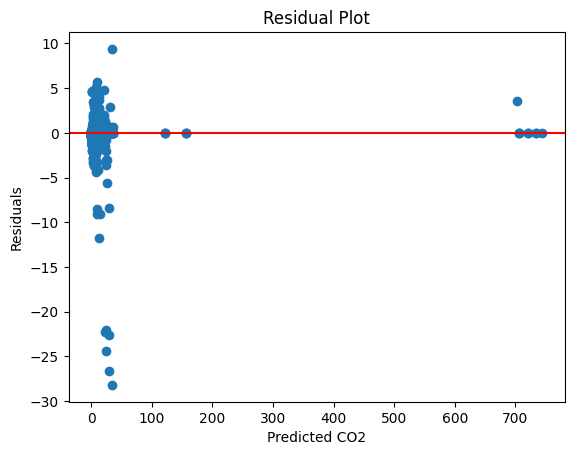

In [51]:
residuals = y_test - y_pred_optimized

plt.scatter(y_pred_optimized, residuals)
plt.axhline(y=0, color='red')
plt.xlabel("Predicted CO2")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

The residual analysis indicates that the model errors are randomly distributed around zero, suggesting that the Random Forest model captures the underlying patterns effectively without systematic bias.

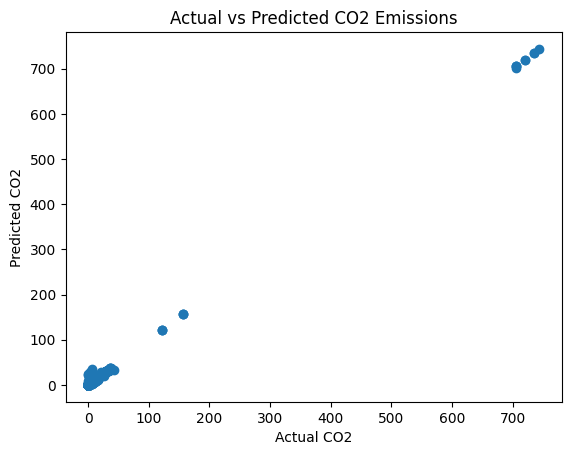

In [52]:
#Actual vs Predicted Plot
plt.scatter(y_test, y_pred_optimized)
plt.xlabel("Actual CO2")
plt.ylabel("Predicted CO2")
plt.title("Actual vs Predicted CO2 Emissions")
plt.show()

The Actual vs Predicted plot shows that most predicted values closely follow the actual CO₂ emissions, indicating strong predictive performance of the model.

In [53]:
#Final Model Comparison Table
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest (Default)", "Random Forest (Tuned)"],
    "R2": [lr_r2, rf_r2, r2_score(y_test, y_pred_optimized)],
    "MAE": [lr_mae, rf_mae, mean_absolute_error(y_test, y_pred_optimized)],
    "RMSE": [lr_rmse, rf_rmse, np.sqrt(mean_squared_error(y_test, y_pred_optimized))]
})

print(comparison)

                     Model        R2       MAE       RMSE
0        Linear Regression  0.568387  9.223323  40.792710
1  Random Forest (Default)  0.998840  0.649138   2.114424
2    Random Forest (Tuned)  0.998913  0.637750   2.047378


In [54]:
# Model Validation (Cross-Validation)
from sklearn.model_selection import cross_val_score

scores = cross_val_score(best_rf, X, y, cv=5, scoring="r2")

print("Cross Validation Scores:", scores)
print("Average CV Score:", scores.mean())

Cross Validation Scores: [0.94082232 0.92612171 0.99453902 0.99509771 0.99718174]
Average CV Score: 0.97075250118546


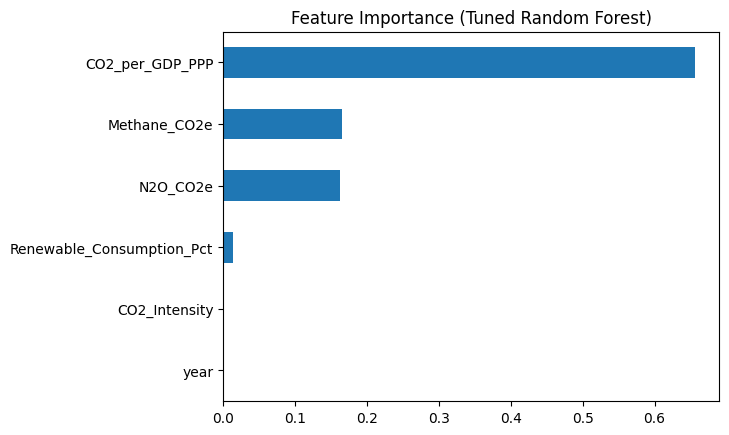

In [55]:
# Feature Importance (Final Model)
importance = pd.Series(best_rf.feature_importances_, index=X.columns)

importance.sort_values().plot(kind="barh")
plt.title("Feature Importance (Tuned Random Forest)")
plt.show()